# Proposition / Multi-Vector Indexing

**Problem:** raw chunks carry noise (boilerplate, formatting) - similarity search matches on messy text.

**Idea:** search on crisp, meaning-dense summaries; answer from the complete parent document.

Flow:
1. Load documents
2. LLM summarizes each doc -> "proposition"
3. Embed propositions -> vector store (search index)
4. Store full docs in a docstore, linked by id
5. Query: semantic match on summary -> fetch parent doc by id

> Terminology: strictly this is *summary-based multi-vector* retrieval. Classic
> proposition indexing decomposes text into atomic, self-contained facts instead of
> summaries - same architecture, different unit.

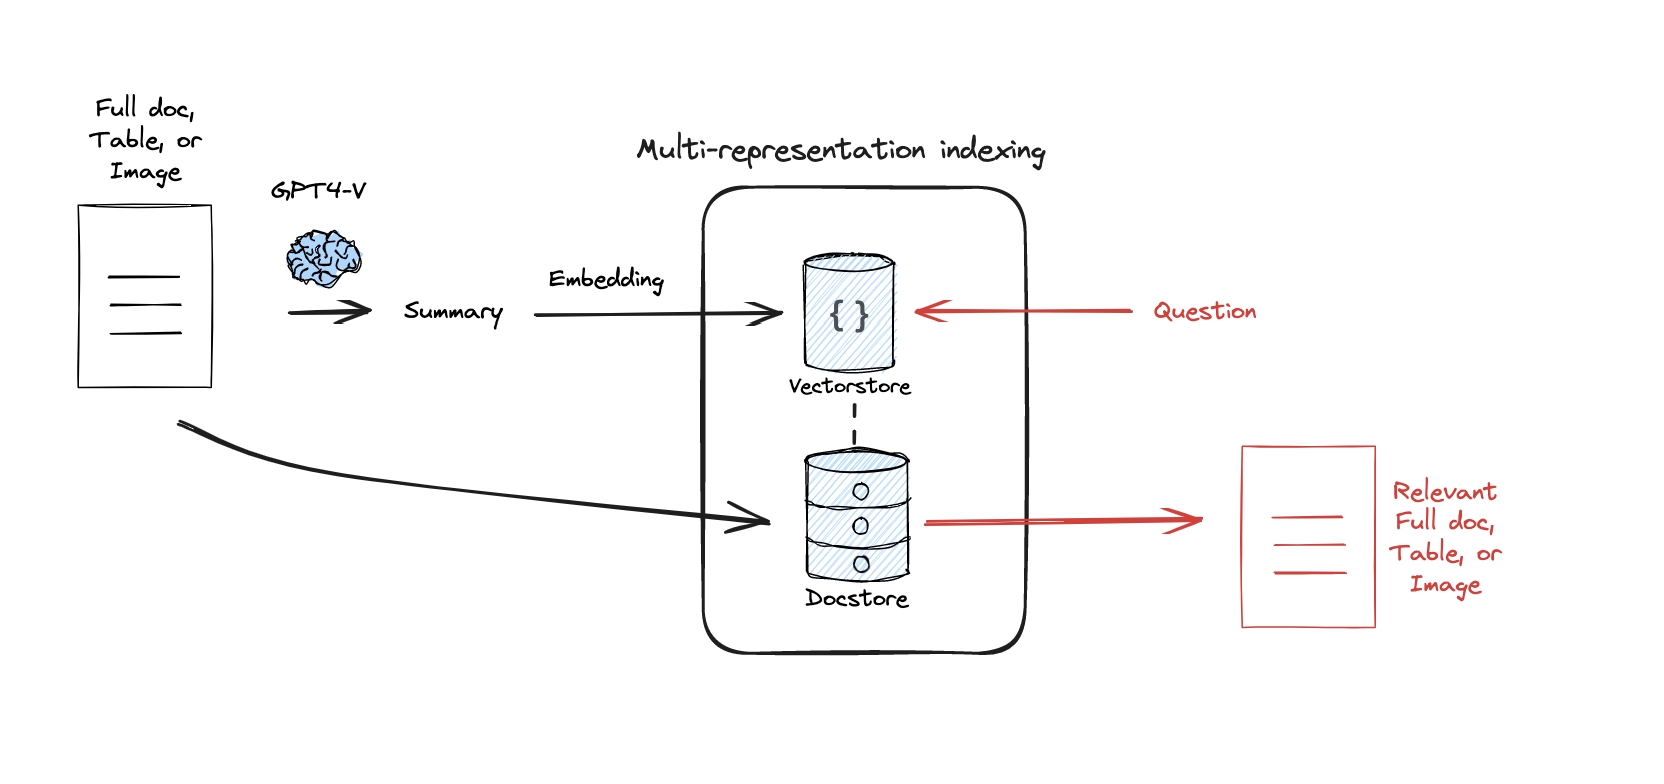

In [15]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="RAG-Indexing"

In [ ]:
# Requires: pip install trafilatura langchain-community

import trafilatura
from langchain_core.documents import Document

rag_prod_grade = "https://developers.llamaindex.ai/python/framework/optimizing/production_rag/"
agentic_ai_prod = "https://mitsloan.mit.edu/ideas-made-to-matter/agentic-ai-explained"

urls = [
    rag_prod_grade,
    agentic_ai_prod
]

documents = []
for url in urls:
    downloaded = trafilatura.fetch_url(url)
    # Extracts main text and converts to markdown while stripping site chrome
    clean_text = trafilatura.extract(
        downloaded, 
        output_format="markdown", 
        include_links=False
    )
    if clean_text:
        documents.append(Document(page_content=clean_text, metadata={"source": url}))

# Each doc now contains only the main article content
documents

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

llm = ChatOllama(model="gemma3:4b")

prompt = ChatPromptTemplate.from_template(
    """
    Summarize the following document:\n\n{doc}
"""
)

sum_chain = {"doc" : lambda x : x.page_content} | prompt | llm | StrOutputParser()

summarized_docs = sum_chain.batch(
    documents, {"max_concurrency": 5}
)

summarized_docs

In [ ]:
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document
from typing import List, Any

class MultiVectorRetriever(BaseRetriever):
    vectorstore: Any
    docstore: Any
    id_key: Any
    k: int = 4
    
    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        sub_docs = self.vectorstore.similarity_search(query, k=self.k)
        
        # 1. Deduplicate IDs to prevent fetching the same parent doc multiple times
        # 2. Filter out None values in case metadata is missing
        parent_ids = list(dict.fromkeys(
            doc.metadata.get(self.id_key) 
            for doc in sub_docs 
            if doc.metadata.get(self.id_key)
        ))
        
        # 3. Filter out missing entries returned from docstore
        parent_docs = self.docstore.mget(parent_ids)
        return [doc for doc in parent_docs if doc is not None]

In [ ]:
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
os.chdir(parent_dir)

print(f"Changed to: {os.getcwd()}")   

In [ ]:
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings

emd_fn = OllamaEmbeddings(model='nomic-embed-text:latest')

vector_store = Chroma(
    embedding_function=emd_fn,
    collection_name="rag-n-agentic",
    persist_directory=os.path.join(os.getcwd(), "chroma.db")
)

In [ ]:
import uuid
import pickle
from langchain_classic.storage import LocalFileStore, EncoderBackedStore

# LocalFileStore is a ByteStore (mset expects bytes), so wrap it with a
# pickle encoder/decoder to store Document objects transparently
store = EncoderBackedStore(
    store=LocalFileStore("doc.db"),
    key_encoder=lambda key: key,
    value_serializer=pickle.dumps,
    value_deserializer=pickle.loads,
)
id_key = "doc_id"

mvr = MultiVectorRetriever(
    docstore=store,
    vectorstore=vector_store,
    id_key=id_key
)

doc_ids = [str(uuid.uuid4()) for _ in documents]

summary_docs = [
    Document(page_content=s, metadata={id_key: doc_ids[i]})
    for i, s in enumerate(summarized_docs)
]

mvr.vectorstore.add_documents(summary_docs)
mvr.docstore.mset(list(zip(doc_ids, documents)))

In [ ]:
question = "What is the fundamental difference between a traditional generative AI chatbot and an AI agent? Give an example where the agent must perceive, reason, use tools, and take action."
query_vs = vector_store.similarity_search(question)
query_vs

In [ ]:
query_ds = mvr.invoke(question)
query_ds

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

llm = ChatOllama(model="gemma3:4b")

prompt = ChatPromptTemplate.from_template("""
Answer the question based only on the following context:

{context}

Question: {question}
""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# mvr = MultiVectorRetriever()

chain = {
    "context": mvr | format_docs,
    "question": RunnablePassthrough()
} | prompt | llm | StrOutputParser()


In [ ]:
agent_questions = [
    "What is the fundamental difference between a traditional generative AI chatbot and an AI agent?",
    "Why does agentic AI introduce greater security and governance risks than a normal chatbot?",
    "Why can data engineering, governance, stakeholder alignment, and workflow integration become the majority of the work when implementing agentic AI?",
    "Why is human oversight particularly important for AI agents when handling exceptions?",
    "How can an organization determine whether an AI agent is actually creating business value?",
]

rag_questions = [
    "Why might the optimal chunk for retrieval be different from the chunk needed by the LLM for answer generation?",
    "Why might basic top-k vector similarity retrieval become unreliable as the number of documents grows, and how can metadata filtering or document hierarchies help?",
    "Why shouldn't every user query use the same retrieval strategy?",
    "Why can embedding a sentence while linking it to its surrounding context be better than embedding a large chunk directly?",
    "Why might a pretrained embedding model perform poorly on a company's specific knowledge base, and how could embedding fine-tuning improve retrieval?"
]

In [ ]:
res1 = chain.batch(rag_questions)
res1 

In [ ]:
res2 = chain.batch(agent_questions)
res2 

### RAPTOR

**Problem:** fixed top-k chunk retrieval misses "big picture" questions whose evidence
is scattered thinly across many chunks or documents.

**Idea:** build a hierarchy instead of a flat index:
- Cluster similar chunks, LLM-summarize each cluster
- Repeat recursively -> tree of increasingly abstract summaries
- Retrieve across ALL levels: details from leaves, themes from upper nodes

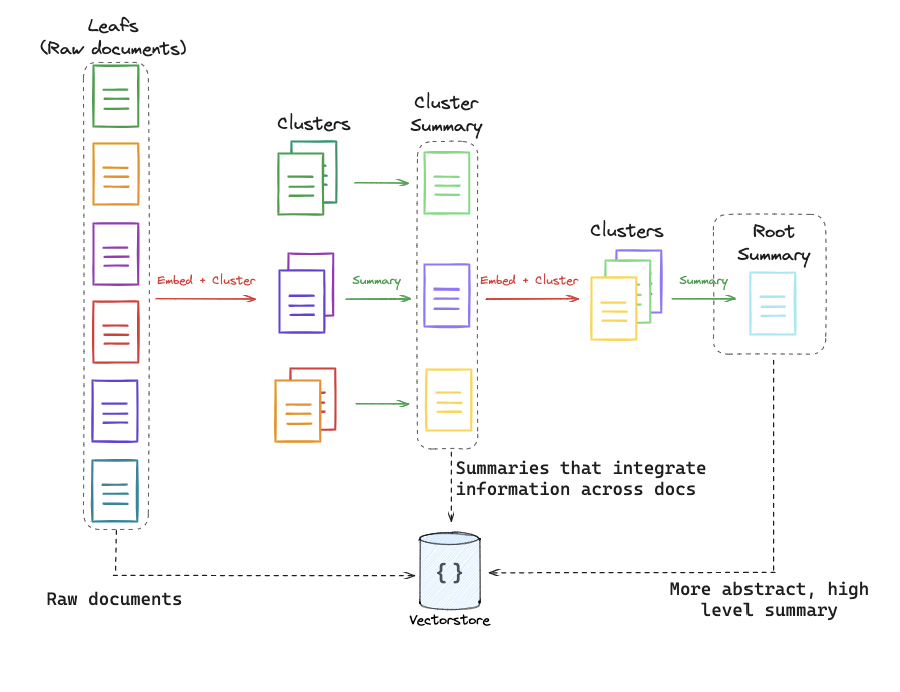

Intentionally skipping this concept for now since it is complex and might take more time to learn. Will Revisit later. More about this concept in following references.

Deep dive video:
https://www.youtube.com/watch?v=jbGchdTL7d0

Paper:
https://arxiv.org/pdf/2401.18059.pdf

Full code:
https://github.com/langchain-ai/langchain/blob/master/cookbook/RAPTOR.ipynb


## ColBERT

**Problem:** dense embeddings compress an entire passage into ONE fixed-length vector - nuance and rare terms blur away.

**Idea:** *late interaction* - keep one vector per token, for queries and passages alike.

- Tokens embedded independently (offline, cacheable, fast)
- Query and document only interact at scoring time (hence "late")
- Retrieval unit = passage; representation = token-level vectors
- Trade-off: far better relevance, much higher storage cost (see PLAID below)

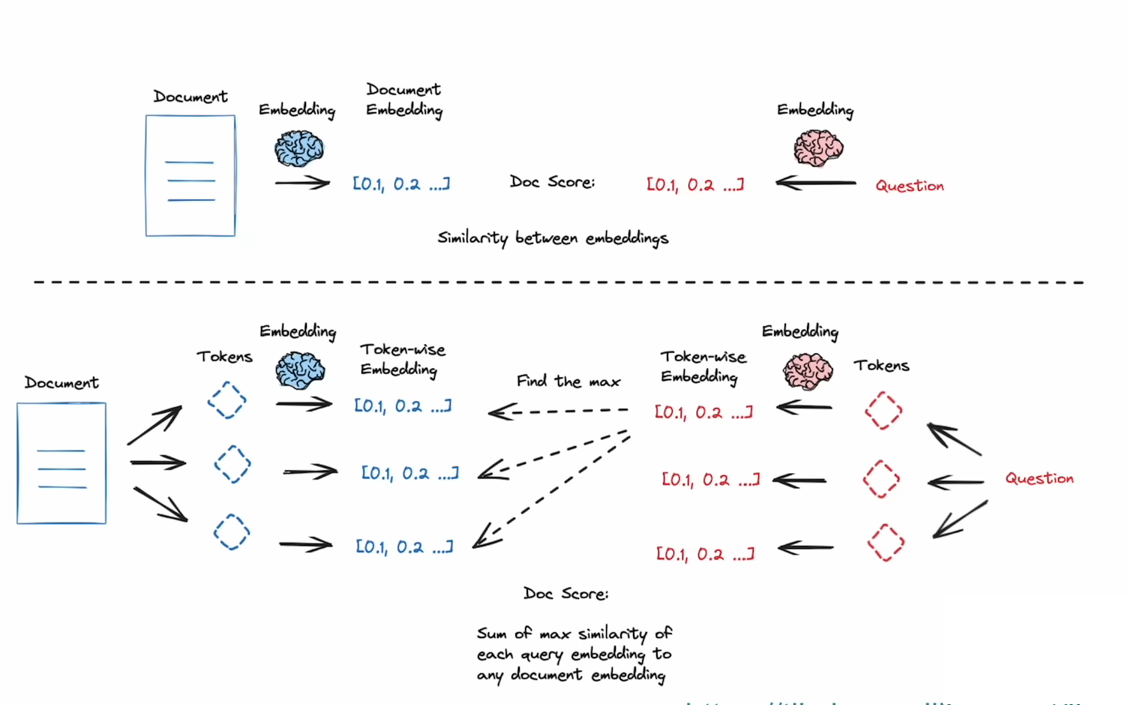

References:

- [How ColBERT Helps Developers Overcome the Limits of RAG](https://hackernoon.com/how-colbert-helps-developers-overcome-the-limits-of-rag)
- [ColBERTv2 paper](https://arxiv.org/abs/2112.01488)

> Tooling note: RAGatouille (the old LangChain-integrated wrapper) is unmaintained and
> pinned to versions < 0.0.10. Its successor is **PyLate** - hands-on port below.

# ColBERT with PyLate

This is a port of the [LangChain RAGatouille integration example](https://docs.langchain.com/oss/python/integrations/retrievers/ragatouille)
to **PyLate** (the actively maintained successor - RAGatouille only works with versions < 0.0.10).

| RAGatouille | PyLate equivalent | What it does |
|---|---|---|
| `RAGPretrainedModel.from_pretrained()` | `models.ColBERT()` | Load a late-interaction model |
| `RAG.index(...)` | `model.encode()` + `index.add_documents()` | Token-level embed + build PLAID index |
| `RAG.search(query, k)` | `retrieve.ColBERT().retrieve(...)` | MaxSim scoring against token vectors |
| `RAG.as_langchain_retriever(k)` | Custom `BaseRetriever` (we write this ourselves!) | Plug into LangChain chains |

> Setup: `uv add pylate` (needs PyTorch). First run downloads the model weights.
> If the notebook kernel is Python 3.14 and torch has no wheel for it yet, create a 3.12 venv for this section.

### Task 1 - Load a pretrained ColBERT model

A ColBERT model does NOT output one vector per document. It outputs **one vector per token**.
That per-token granularity is what enables "late interaction": query tokens and document tokens
are embedded independently (fast, pre-computed) and only interact at scoring time via MaxSim.

In [2]:
from pylate import indexes, models, retrieve

model = models.ColBERT(model_name_or_path="lightonai/GTE-ModernColBERT-v1")

Loading weights: 100%|██████████| 134/134 [00:00<00:00, 3135.05it/s]


### Task 2 - Get documents (same Wikipedia example as the LangChain docs)

In [5]:
import requests


def get_wikipedia_page(title: str):
    URL = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "titles": title,
        "prop": "extracts",
        "explaintext": True,
    }
    headers = {"User-Agent": "rag-learning/0.0.1"}
    response = requests.get(URL, params=params, headers=headers)
    data = response.json()
    page = next(iter(data["query"]["pages"].values()))
    return page.get("extract")


full_document = get_wikipedia_page("Hayao_Miyazaki")
print(len(full_document), "chars")

70651 chars


### Task 3 - Split into passages

The RAGatouille example passed `max_document_length=180, split_documents=True` to `RAG.index()`
and the splitting happened invisibly inside the library. PyLate keeps this step explicit:
ColBERT indexes short **passages**, not whole articles (token vectors are big - a 10k-char article
would produce thousands of them). We use the same splitter you already know from `rag_chunking`.

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

spliter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
passages = spliter.split_text(full_document)

print(f"{len(passages)} passages")
passages[:2]

119 passages


['Hayao Miyazaki (宮崎 駿 or 宮﨑 駿, Miyazaki Hayao; [mijaꜜzaki hajao]; born January 5, 1941) is a Japanese animator, filmmaker, and manga artist. He co-founded Studio Ghibli and serves as its honorary chairman. Throughout his career, Miyazaki has attained international acclaim as a masterful storyteller and creator of Japanese animated feature films, and is widely regarded as one of the greatest and most accomplished filmmakers in the history of animation.',
 "Born in Tokyo City, Miyazaki expressed interest in manga and animation from an early age. He joined Toei Animation in 1963, working as an inbetween artist and key animator on films like Gulliver's Travels Beyond the Moon (1965), The Great Adventure of Horus, Prince of the Sun (1968), and Animal Treasure Island (1971), before moving to A-Pro in 1971, where he co-directed Lupin the Third Part I (1971–1972) with Isao Takahata. After moving to Zuiyō Eizō (later Nippon Animation) in 1973, Miyazaki worked as an animator on World Masterpiec

### Task 4 - Build a PLAID index

PLAID compresses token vectors with product quantization (~10x smaller storage) and uses
two-stage centroid scoring for fast search. `override=True` rebuilds it fresh on re-runs.
Notice we also create the retriever object up front - unlike Chroma, index and searcher are separate.

In [7]:
index = indexes.PLAID(
    index_folder="pylate-index",
    index_name="miyazaki",
    override=True,
)

retriever = retrieve.ColBERT(index=index)

### Task 5 - Encode documents and add to the index

`is_query=False` matters: queries and documents are tokenized differently in ColBERT
(queries get padded/marked so MaxSim works symmetrically).
Inspect `documents_embeddings[0].shape` below - it is `(num_tokens, embedding_dim)`,
NOT a single flat vector like `nomic-embed-text` would give you. This is the core difference.

In [8]:
documents_ids = [str(i) for i in range(len(passages))]

documents_embeddings = model.encode(
    passages,
    batch_size=32,
    is_query=False,
    show_progress_bar=True,
)

index.add_documents(
    documents_ids=documents_ids,
    documents_embeddings=documents_embeddings,
)

print(f"passage 0 -> {len(passages[0].split())} words -> {documents_embeddings[0].shape} token vectors")

Encoding documents (bs=32): 100%|██████████| 4/4 [00:33<00:00,  8.44s/it]


passage 0 -> 70 words -> (116, 128) token vectors


### Task 6 - Retrieve with MaxSim scoring

For each query token, ColBERT finds its best-matching document token (MaxSim);
the final score is the sum over all query tokens. High score = many query tokens
found strong counterparts in the passage.
`retrieve()` returns ranked `[{"id", "score"}]` dicts - we map ids back to text ourselves.

In [9]:
query = "What animation studio did Miyazaki found?"

queries_embeddings = model.encode([query], is_query=True)

scores = retriever.retrieve(queries_embeddings=queries_embeddings, k=3)[0]

id_to_passage = dict(zip(documents_ids, passages))
for hit in scores:
    print(f"score={hit['score']:.3f} | {id_to_passage[hit['id']][:150]}...")

score=11.352 | Hayao Miyazaki (宮崎 駿 or 宮﨑 駿, Miyazaki Hayao; [mijaꜜzaki hajao]; born January 5, 1941) is a Japanese animator, filmmaker, and manga artist. He co-foun...
score=11.332 | Production began on May 31, 1983, with animation beginning in August; funding was provided through a joint venture between Tokuma Shoten and the adver...
score=11.301 | led to disappointing box office results—among Toei Animation's worst, which threatened the studio financially. Miyazaki moved to a residence in Higash...


### Task 7 - Wrap it as a LangChain Retriever

RAGatouille gave you `RAG.as_langchain_retriever(k=3)` for free.
PyLate has no such adapter, so we write it ourselves - exactly like the
`MultiVectorRetriever(BaseRetriever)` you built earlier in this notebook.
Same pattern: pydantic fields, implement `_get_relevant_documents`, done.

In [16]:
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document
from typing import List, Any


class ColBERTRetriever(BaseRetriever):
    model: Any
    plaid_retriever: Any
    passage_map: dict
    k: int = 3

    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        query_embedding = self.model.encode([query], is_query=True)
        hits = self.plaid_retriever.retrieve(queries_embeddings=query_embedding, k=self.k)[0]
        return [
            Document(
                page_content=self.passage_map[hit["id"]],
                metadata={"score": hit["score"]},
            )
            for hit in hits
        ]


colbert_retriever = ColBERTRetriever(
    model=model,
    plaid_retriever=retriever,
    passage_map=id_to_passage,
    k=3,
)
colbert_retriever.invoke("What animation studio did Miyazaki found?")

{'0': 'Hayao Miyazaki (宮崎 駿 or 宮﨑 駿, Miyazaki Hayao; [mijaꜜzaki hajao]; born January 5, 1941) is a Japanese animator, filmmaker, and manga artist. He co-founded Studio Ghibli and serves as its honorary chairman. Throughout his career, Miyazaki has attained international acclaim as a masterful storyteller and creator of Japanese animated feature films, and is widely regarded as one of the greatest and most accomplished filmmakers in the history of animation.', '1': "Born in Tokyo City, Miyazaki expressed interest in manga and animation from an early age. He joined Toei Animation in 1963, working as an inbetween artist and key animator on films like Gulliver's Travels Beyond the Moon (1965), The Great Adventure of Horus, Prince of the Sun (1968), and Animal Treasure Island (1971), before moving to A-Pro in 1971, where he co-directed Lupin the Third Part I (1971–1972) with Isao Takahata. After moving to Zuiyō Eizō (later Nippon Animation) in 1973, Miyazaki worked as an animator on World M

[Document(metadata={'score': 11.3515625}, page_content='Hayao Miyazaki (宮崎 駿 or 宮﨑 駿, Miyazaki Hayao; [mijaꜜzaki hajao]; born January 5, 1941) is a Japanese animator, filmmaker, and manga artist. He co-founded Studio Ghibli and serves as its honorary chairman. Throughout his career, Miyazaki has attained international acclaim as a masterful storyteller and creator of Japanese animated feature films, and is widely regarded as one of the greatest and most accomplished filmmakers in the history of animation.'),
 Document(metadata={'score': 11.33203125}, page_content="Production began on May 31, 1983, with animation beginning in August; funding was provided through a joint venture between Tokuma Shoten and the advertising agency Hakuhodo, for whom Miyazaki's youngest brother worked. Animation studio Topcraft was chosen as the production house. Miyazaki found some of Topcraft's staff unreliable, and brought on several of his previous collaborators, including Takahata, who served as producer

### Task 8 - Plug into the same LCEL RAG chain you already have

Because our retriever is a proper Runnable, it drops straight into the identical
chain pattern used above with `mvr`. Compare answers side-by-side:

In [17]:
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(model="gemma3:4b")

prompt = ChatPromptTemplate.from_template("""
Answer the question based only on the following context:

{context}

Question: {question}
""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

colbert_chain = {
    "context": colbert_retriever | format_docs,
    "question": RunnablePassthrough(),
} | prompt | llm | StrOutputParser()

colbert_chain.invoke("What animation studio did Miyazaki found?")

[{'id': '0', 'score': 11.3515625}, {'id': '35', 'score': 11.33203125}, {'id': '16', 'score': 11.30078125}]


'According to the text, Miyazaki co-founded **Studio Ghibli**.'